In [1]:
# Core tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="pastel")

# Modeling tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv("Cleaned_Final.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 51 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Age                                                              2022 non-null   float64
 1   Academic_Year                                                    2022 non-null   int64  
 2   Current_CGPA                                                     2022 non-null   float64
 3   waiver_or_scholarship                                            2022 non-null   int64  
 4   PSS1                                                             2022 non-null   int64  
 5   PSS2                                                             2022 non-null   int64  
 6   PSS3                                                             2022 non-null   int64  
 7   PSS4                                      

In [3]:
# ===============================
# 🧪 Feature Selection & Train-Test Split
# ===============================

# 1. Drop PHQ items and leakage-related columns
phq_cols = [col for col in df.columns if col.startswith("PHQ")]
leakage_cols = [
    "Depression_Value", "Anxiety_Value", "Stress_Value",
    "Anxiety_Label", "Stress_Label"
]
columns_to_drop = [col for col in phq_cols + leakage_cols if col in df.columns]

# 2. Target before dropping
y = df["Depression_Label"]

# 3. Drop leakage columns
X = df.drop(columns=columns_to_drop + ["Depression_Label"])

# 4. Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 6. Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 7. Class label mapping (for interpretation)
label_encoder.classes_


array(['Mild Depression', 'Minimal Depression', 'Moderate Depression',
       'Moderately Severe Depression', 'No Depression',
       'Severe Depression'], dtype=object)

In [4]:
import xgboost 

In [5]:
# ===============================
# ⚙️ Train & Evaluate: Logistic, Random Forest, XGBoost
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Model setup
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
}

# Train & evaluate
for name, model in models.items():
    print(f"\n🔍 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (weighted): {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



🔍 Logistic Regression
Accuracy: 0.4667
F1 Score (weighted): 0.4597
Classification Report:
                              precision    recall  f1-score   support

             Mild Depression       0.48      0.55      0.51        82
          Minimal Depression       0.45      0.25      0.32        20
         Moderate Depression       0.34      0.29      0.31        91
Moderately Severe Depression       0.40      0.39      0.39       102
               No Depression       1.00      0.56      0.71         9
           Severe Depression       0.58      0.67      0.62       101

                    accuracy                           0.47       405
                   macro avg       0.54      0.45      0.48       405
                weighted avg       0.46      0.47      0.46       405


🔍 Random Forest
Accuracy: 0.5086
F1 Score (weighted): 0.5005
Classification Report:
                              precision    recall  f1-score   support

             Mild Depression       0.52      0.57 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [12:36:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.4938
F1 Score (weighted): 0.4884
Classification Report:
                              precision    recall  f1-score   support

             Mild Depression       0.51      0.61      0.56        82
          Minimal Depression       0.55      0.30      0.39        20
         Moderate Depression       0.41      0.31      0.35        91
Moderately Severe Depression       0.41      0.47      0.44       102
               No Depression       0.75      0.67      0.71         9
           Severe Depression       0.60      0.61      0.61       101

                    accuracy                           0.49       405
                   macro avg       0.54      0.49      0.51       405
                weighted avg       0.49      0.49      0.49       405



In [9]:
# Save trained Random Forest and XGBoost models after the loop
rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]

# Create importance objects
importances_rf = rf_model.feature_importances_
importances_xgb = xgb_model.feature_importances_

# Build feature importance series
features_rf = pd.Series(importances_rf, index=X.columns).sort_values(ascending=False)
features_xgb = pd.Series(importances_xgb, index=X.columns).sort_values(ascending=False)


/var/folders/8y/7z7bnlwn40s6mhwg565vp_4w0000gn/T/ipykernel_23406/3065831036.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features_rf_top.values, y=features_rf_top.index, ax=axes[0], palette="viridis")
/var/folders/8y/7z7bnlwn40s6mhwg565vp_4w0000gn/T/ipykernel_23406/3065831036.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features_xgb_top.values, y=features_xgb_top.index, ax=axes[1], palette="rocket")
/var/folders/8y/7z7bnlwn40s6mhwg565vp_4w0000gn/T/ipykernel_23406/3065831036.py:28: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  plt.tight_layout()
/var/folders/8y/7z7bnlwn40s6mhwg565vp_4w0000gn/T/ipykernel_23406/3065831036.py:28: UserWarning: G

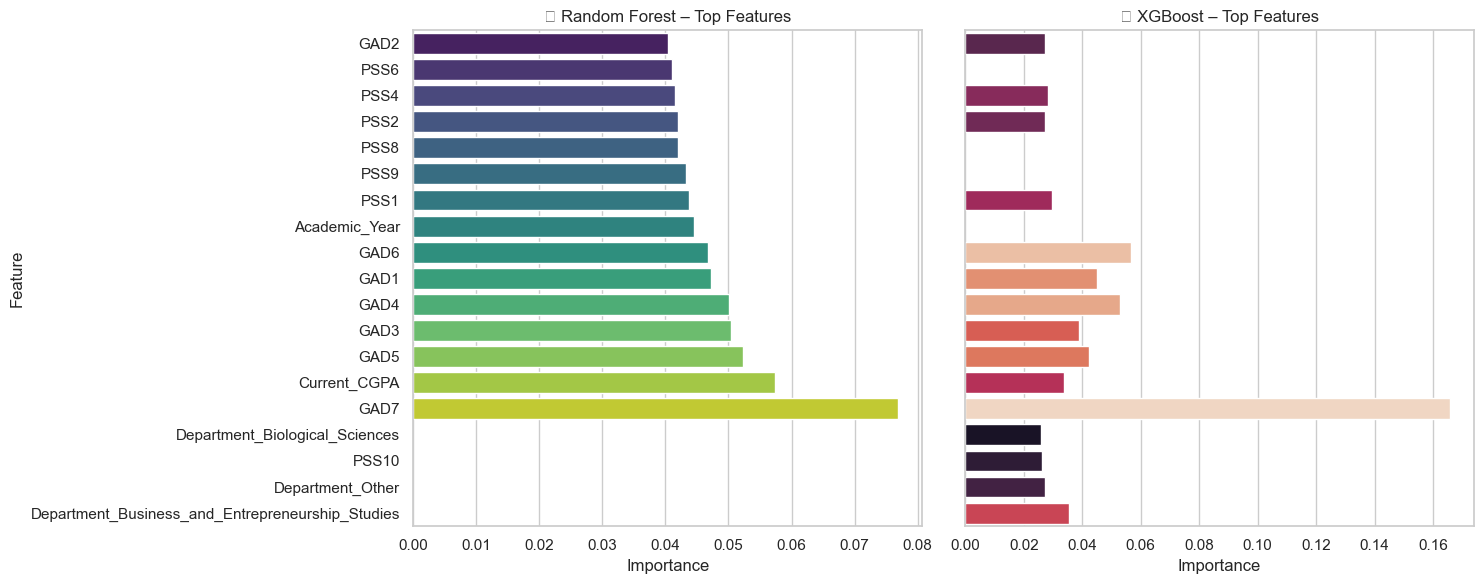

In [10]:
# ===============================
# 📊 Top Feature Importance Comparison – RF & XGB
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt

# Prepare top N features
top_n = 15
features_rf_top = features_rf.head(top_n).sort_values()
features_xgb_top = features_xgb.head(top_n).sort_values()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Random Forest
sns.barplot(x=features_rf_top.values, y=features_rf_top.index, ax=axes[0], palette="viridis")
axes[0].set_title("🌲 Random Forest – Top Features")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

# XGBoost
sns.barplot(x=features_xgb_top.values, y=features_xgb_top.index, ax=axes[1], palette="rocket")
axes[1].set_title("⚡ XGBoost – Top Features")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
